In [1]:
import mdtraj as md
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import shutil

In [67]:
from metfish.utils import get_Pr

# Dictionary for checking pairs

In [68]:
with open("protein_analysis.pkl", "rb") as f:
    loaded_data = pickle.load(f)

rows = loaded_data["rows"]
results_dict = loaded_data["results_dict"]
contact_dict = loaded_data["contact_dict"]
contact_ref = loaded_data["contact_ref"]

In [69]:
pair_csv=pd.read_csv('/global/cfs/cdirs/m4704/100125_Nature_Com_data/Apo_holo_data/Table_rmsd_Apo_vs_Holo.csv',sep=';')

In [70]:
pair_dict={}
for index, i in pair_csv.iterrows():
    pair_dict[i['Apo_ID']]=i['Holo_ID']
    pair_dict[i['Holo_ID']]=i['Apo_ID']

In [71]:
len(pair_dict)

190

In [72]:
pair_dict['2RS9-13_B']

'2D9E-12_A'

# Functions

In [73]:
def extract_ensemble(output_path, pdb_id):
    loss_csv=os.path.join(output_path, pdb_id, 'saved_structures.csv')
    loss_pd=pd.read_csv(loss_csv)
    loss_pd=loss_pd[~loss_pd['full_path'].str.contains('best')]
    loss_pd=loss_pd.sort_values(by='loss').reset_index(drop=True).head(50)
    return loss_pd

In [74]:
def calc_Heli(t,length):
    dssp = md.compute_dssp(t)
    dssp_count = np.zeros((1, length))
    for j in range(t.n_residues):
            if dssp[0,j] in 'H':
                dssp_count[0,j] += 1
    summary = dssp_count.sum(axis=1)
    return(summary[0]/length)

def calc_Beta(t,length):
    dssp = md.compute_dssp(t)
    dssp_count = np.zeros((1, t.n_residues))
    for j in range(t.n_residues):
        if dssp[0,j] in 'E':
            dssp_count[0,j] += 1
    summary = dssp_count.sum(axis=1)
    return(summary[0]/length)

def calc_Rg(t):
    d = md.compute_rg(t)
    return(d[0])
    
def calc_Re(t):
    topology=t.topology
    rpology=topology.select_atom_indices(selection='alpha')
    d = md.compute_distances(t,[[rpology[0],rpology[-1]]])
    return(d[0][0])

def calc_contact(t):
    contact=md.compute_contacts(t, contacts='all', scheme='ca')
    # Use distance or the contact?
    contact_square=md.geometry.squareform(contact[0]<0.8,contact[1])
    #contact_square=md.geometry.squareform(contact[0],contact[1])
    return contact_square[0]

In [88]:
def l1_loss_padded(y_true, y_pred, pad_value=0):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    len_true = y_true.shape[0]
    len_pred = y_pred.shape[0]
    
    if len_true < len_pred:
        y_true = np.pad(y_true, (0, len_pred - len_true), constant_values=pad_value)
    elif len_pred < len_true:
        y_pred = np.pad(y_pred, (0, len_true - len_pred), constant_values=pad_value)
    return np.sum(np.abs(y_true - y_pred))

def l1_loss_calculation(target_path, ref_path):
    ref_saxs=get_Pr(ref_path, None, None, 0.5)
    target_saxs=get_Pr(target_path, None, None, 0.5)
    return l1_loss_padded(ref_saxs[1],target_saxs[1])

In [89]:
def analyze_conformation(confor_path):
    result_dic={}
    confor_frame = md.load(confor_path)
    length = confor_frame.n_residues
    confor_rg = calc_Rg(confor_frame)
    confor_re = calc_Re(confor_frame)
    confor_helicity =  calc_Heli(confor_frame,length)
    confor_beta = calc_Beta(confor_frame,length)
    confor_contact = calc_contact(confor_frame)
    result_dict={'seq_length':length,
                'rg':confor_rg,
                're':confor_re,
                'helicity':confor_helicity,
                'beta':confor_beta,}
    return result_dict, confor_contact, confor_frame

In [90]:
def generate_rmsd_alphaSAXS_pair(pdb_id,ref_path,output_path,pair_id):
    results=[]
    contact_maps=[]
    ref_result, ref_contact, ref_t = analyze_conformation(os.path.join(ref_path,pdb_id+'.pdb'))
    ref_atom=ref_t.topology.select('name CA')
    ref_result_pair, ref_contact_pair, ref_t_pair = analyze_conformation(os.path.join(ref_path,pair_id+'.pdb'))
    ref_atom_pair=ref_t_pair.topology.select('name CA')

    ref_result['ref_to_pair_saxs_loss']=l1_loss_calculation(os.path.join(ref_path,pair_id+'.pdb')
                                                            ,os.path.join(ref_path,pdb_id+'.pdb'))

    
    generated_pdb_df = extract_ensemble(output_path,pdb_id)
    for index, single_pdb in generated_pdb_df.iterrows():
        saxs_loss = single_pdb['loss']
        result_dict, confor_contact, confor_frame = analyze_conformation(single_pdb['full_path'])
        contact_maps.append(confor_contact)
        confor_atom=confor_frame.topology.select('name CA')
        if len(confor_atom)!=len(ref_atom):
            print(pdb_id+' has the wrong length')
            print(test_frame, len(test_atom), ref_t, len(ref_atom))
            continue
        ca_rmsd=md.rmsd(confor_frame,ref_t,0,confor_atom,ref_atom)
        ca_rmsd_pair=md.rmsd(confor_frame,ref_t_pair,0,confor_atom,ref_atom_pair)
        result_dict['rmsd']=ca_rmsd[0]*10
        result_dict['rmsd_pair']=ca_rmsd_pair[0]*10
        result_dict['saxs_loss']=saxs_loss
        result_dict['pair_saxs_loss']=l1_loss_calculation(os.path.join(ref_path,pair_id+'.pdb'),single_pdb['full_path'])
        results.append(result_dict)
    averages = {
    key: np.mean([r[key] for r in results])
    for key in results[0].keys()
}
    best = min(results, key=lambda d: d['rmsd'])
    return averages,ref_result, contact_maps,ref_contact,results,best

In [91]:
def flatten_contact_map(cm):
    # Use upper triangle without diagonal
    return cm[np.triu_indices_from(cm, k=1)]

In [92]:
def rmsd_ensemble(ensemble):
    result=[]
    result_pair=[]
    for i in ensemble:
            result.append(i['rmsd'])
            result_pair.append(i['rmsd_pair'])
    return result, result_pair

In [93]:
def rg_ensemble(ensemble,ref,ref_pair):
    result=[]
    result_pair=[]
    for i in ensemble:
            result.append(i['rg']-ref['rg'])
            result_pair.append(i['rg']-ref_pair['rg'])
    return result, result_pair

In [94]:
def save_ensemble(output_path,pdb_id,ensemble_df):
    dest_folder = os.path.join(output_path, pdb_id)
    os.makedirs(dest_folder, exist_ok=True)
    copied_count = 0
    for src in ensemble_df['full_path']:
        if os.path.isfile(src):  # Check if source file exists
            shutil.copy(src, dest_folder)
            copied_count += 1
        else:
            print(f"Missing file: {src}")
    ensemble_df.to_csv(os.path.join(dest_folder,pdb_id+'_ranking.csv'))
    print(f"✅ Copied {copied_count} files to {dest_folder}")

# Example Analysis

In [95]:
output_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/ensemble_generated/ensembles'
ref_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/Apo_holo_data/pdbs'

In [96]:
save_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/ensemble_generated/sub_ensembles'

In [97]:
#save_ensemble(save_path, '1JFJ-3_A', extract_ensemble(output_path,'1JFJ-3_A'))

In [98]:
#save_ensemble(save_path, '1JFK_A', extract_ensemble(output_path,'1JFK_A'))

In [99]:
pair_dict={}

In [100]:
averages,ref_result, contact_maps,ref_contact,results, best= generate_rmsd_alphaSAXS_pair('1JFJ-3_A',ref_path,output_path,'1JFK_A')
pair_dict['apo_ensemble']=contact_maps
pair_dict['apo_shape']=results
pair_dict['apo_ref']=ref_contact
pair_dict['apo_ref_shape']=ref_result

/global/homes/l/lemonboy/.local/perlmutter/python-3.11/lib/python3.11/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'TER' at line 1920
  warnings.warn(
/global/homes/l/lemonboy/.local/perlmutter/python-3.11/lib/python3.11/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'TER' at line 2093
  warnings.warn(
/global/homes/l/lemonboy/.local/perlmutter/python-3.11/lib/python3.11/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'END' at line 1055
  warnings.warn(
/global/homes/l/lemonboy/.local/perlmutter/python-3.11/lib/python3.11/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'TER' at line 2093
  warnings.warn(
/global/homes/l/lemonboy/.local/perlmutter/python-3.11/lib/python3.11/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'END' at line 1055
  warnings.warn(
/glob

In [101]:
averages,ref_result, contact_maps,ref_contact,results, best= generate_rmsd_alphaSAXS_pair('1JFK_A',ref_path,output_path,'1JFJ-3_A')
pair_dict['holo_ensemble']=contact_maps
pair_dict['holo_shape']=results
pair_dict['holo_ref']=ref_contact
pair_dict['holo_ref_shape']=ref_result

/global/homes/l/lemonboy/.local/perlmutter/python-3.11/lib/python3.11/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'TER' at line 2093
  warnings.warn(
/global/homes/l/lemonboy/.local/perlmutter/python-3.11/lib/python3.11/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'TER' at line 1920
  warnings.warn(
/global/homes/l/lemonboy/.local/perlmutter/python-3.11/lib/python3.11/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'END' at line 1055
  warnings.warn(
/global/homes/l/lemonboy/.local/perlmutter/python-3.11/lib/python3.11/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'TER' at line 1920
  warnings.warn(
/global/homes/l/lemonboy/.local/perlmutter/python-3.11/lib/python3.11/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'END' at line 1055
  warnings.warn(
/glob

In [66]:
ref_result

{'seq_length': 134,
 'rg': 1.7344536758887084,
 're': 2.1850386,
 'helicity': 0.5746268656716418,
 'beta': 0.08955223880597014}

In [47]:
!pwd

/global/cfs/cdirs/m4704/100125_Nature_Com_data/ensemble_generated/notebooks


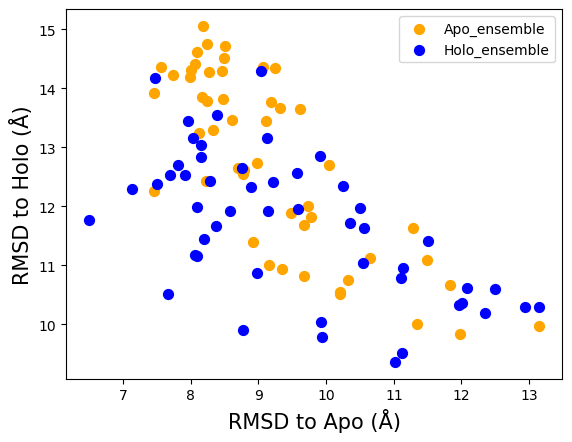

In [51]:
apo_apo_rmsd,apo_holo_rmsd=rmsd_ensemble(pair_dict['apo_shape'])
holo_holo_rmsd,holo_apo_rmsd=rmsd_ensemble(pair_dict['holo_shape'])
plt.scatter(apo_apo_rmsd, apo_holo_rmsd, color='orange', label='Apo_ensemble', marker='.', s=200)
plt.scatter(holo_apo_rmsd, holo_holo_rmsd, color='blue', label='Holo_ensemble', marker='.', s=200)
plt.xlabel('RMSD to Apo (Å)',fontsize=15)
plt.ylabel('RMSD to Holo (Å)',fontsize=15)
plt.legend()
plt.savefig('RMSD_Apo.png')

In [28]:
apo_rg=[i['rg'] for i in pair_dict['apo_shape']]
holo_rg=[i['rg'] for i in pair_dict['holo_shape']]

In [29]:
apo_re=[i['re'] for i in pair_dict['apo_shape']]
holo_re=[i['re'] for i in pair_dict['holo_shape']]

In [30]:
apo_ref_rg=pair_dict['apo_ref_shape']['rg']
apo_ref_re=pair_dict['apo_ref_shape']['re']
holo_ref_rg=pair_dict['holo_ref_shape']['rg']
holo_ref_re=pair_dict['holo_ref_shape']['re']

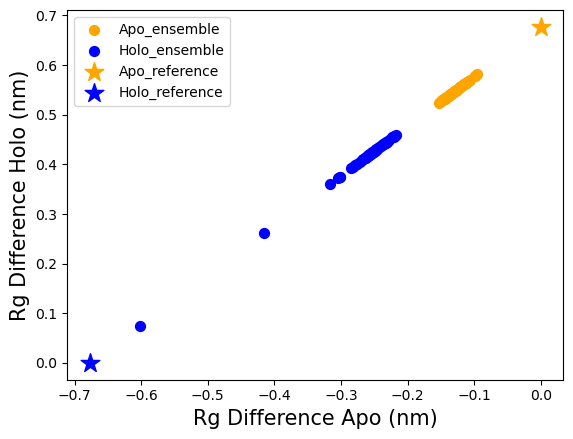

In [50]:
apo_apo_rg,apo_holo_rg=rg_ensemble(pair_dict['apo_shape'],pair_dict['apo_ref_shape'],pair_dict['holo_ref_shape'])
holo_holo_rg,holo_apo_rg=rg_ensemble(pair_dict['holo_shape'],pair_dict['holo_ref_shape'],pair_dict['apo_ref_shape'])
plt.scatter(apo_apo_rg, apo_holo_rg, color='orange', label='Apo_ensemble', marker='.', s=200)
plt.scatter(holo_apo_rg, holo_holo_rg, color='blue', label='Holo_ensemble', marker='.', s=200)
plt.scatter(apo_ref_rg-apo_ref_rg,apo_ref_rg-holo_ref_rg,label='Apo_reference',color='orange', marker='*', s=200)
plt.scatter(holo_ref_rg-apo_ref_rg,holo_ref_rg-holo_ref_rg, label='Holo_reference',color='blue', marker='*', s=200)
plt.xlabel('Rg Difference Apo (nm)',fontsize=15)
plt.ylabel('Rg Difference Holo (nm)',fontsize=15)
plt.legend()
plt.savefig('Rg_Apo.png')

In [102]:
apo_holo_saxs=[i['pair_saxs_loss'] for i in pair_dict['apo_shape']]
apo_apo_saxs=[i['saxs_loss'] for i in pair_dict['apo_shape']]
holo_apo_saxs=[i['pair_saxs_loss'] for i in pair_dict['holo_shape']]
holo_holo_saxs=[i['saxs_loss'] for i in pair_dict['holo_shape']]

In [104]:
apo_ref_saxs = pair_dict['apo_ref_shape']['ref_to_pair_saxs_loss']
holo_ref_saxs = pair_dict['holo_ref_shape']['ref_to_pair_saxs_loss']

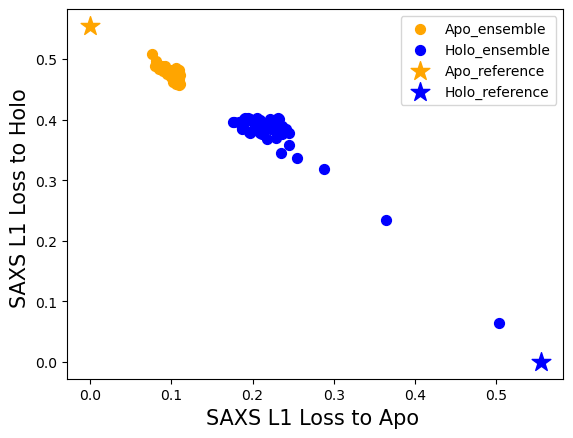

In [105]:
plt.scatter(apo_apo_saxs, apo_holo_saxs, color='orange', label='Apo_ensemble', marker='.', s=200)
plt.scatter(holo_apo_saxs, holo_holo_saxs, color='blue', label='Holo_ensemble', marker='.', s=200)
plt.scatter(0,apo_ref_saxs,label='Apo_reference',color='orange', marker='*', s=200)
plt.scatter(holo_ref_saxs,0, label='Holo_reference',color='blue', marker='*', s=200)
plt.xlabel('SAXS L1 Loss to Apo ',fontsize=15)
plt.ylabel('SAXS L1 Loss to Holo ',fontsize=15)
plt.legend()

In [ ]:
# Maybe a barplot for all of them

# Analysis Function

In [40]:
def analysis_plot(ref_path, output_path, apo_pdb_id, holo_pdb_id):
    """
    Generate RMSD and Rg comparison plots for apo and holo ensembles.

    Parameters
    ----------
    ref_path : str
        Path to the reference structure files.
    output_path : str
        Path to save the output plots.
    apo_pdb_id : str
        PDB identifier for the apo form.
    holo_pdb_id : str
        PDB identifier for the holo form.
    """
    
    def run_pair_analysis(id1, id2):
        """Helper to run generate_rmsd_alphaSAXS_pair and package results."""
        averages, ref_result, contact_maps, ref_contact, results, best = generate_rmsd_alphaSAXS_pair(id1, ref_path, output_path, id2)
        return {
            "ensemble": contact_maps,
            "shape": results,
            "ref_contact": ref_contact,
            "ref_shape": ref_result
        }
    
    # Run both apo->holo and holo->apo analyses
    pair_dict = {
        "apo": run_pair_analysis(apo_pdb_id, holo_pdb_id),
        "holo": run_pair_analysis(holo_pdb_id, apo_pdb_id)
    }
    
    # Calculate RMSD
    apo_apo_rmsd, apo_holo_rmsd = rmsd_ensemble(pair_dict["apo"]["shape"])
    holo_holo_rmsd, holo_apo_rmsd = rmsd_ensemble(pair_dict["holo"]["shape"])
    
    # Calculate Rg differences
    apo_apo_rg, apo_holo_rg = rg_ensemble(pair_dict["apo"]["shape"],
                                          pair_dict["apo"]["ref_shape"],
                                          pair_dict["holo"]["ref_shape"])
    holo_holo_rg, holo_apo_rg = rg_ensemble(pair_dict["holo"]["shape"],
                                            pair_dict["holo"]["ref_shape"],
                                            pair_dict["apo"]["ref_shape"])
    
    # Plotting
    fig, axs = plt.subplots(2, 1, figsize=(5, 10))
    
    # RMSD plot
    axs[0].scatter(apo_apo_rmsd, apo_holo_rmsd, color='blue', label='Apo Ensemble', marker='.', s=200)
    axs[0].scatter(holo_apo_rmsd, holo_holo_rmsd, color='orange', label='Holo Ensemble', marker='.', s=200)
    axs[0].set_xlabel('RMSD to Apo (Å)', fontsize=15)
    axs[0].set_ylabel('RMSD to Holo (Å)', fontsize=15)
    axs[0].legend()
    
    # Rg plot
    axs[1].scatter(apo_apo_rg, apo_holo_rg, color='blue', label='Apo Ensemble', marker='.', s=200)
    axs[1].scatter(holo_apo_rg, holo_holo_rg, color='orange', label='Holo Ensemble', marker='.', s=200)
    axs[1].set_xlabel('Rg Difference Apo (nm)', fontsize=15)
    axs[1].set_ylabel('Rg Difference Holo (nm)', fontsize=15)
    axs[1].legend()
    plt.savefig(apo_pdb_id+'png', bbox_inches='tight', pad_inches=0.2)
    plt.show()

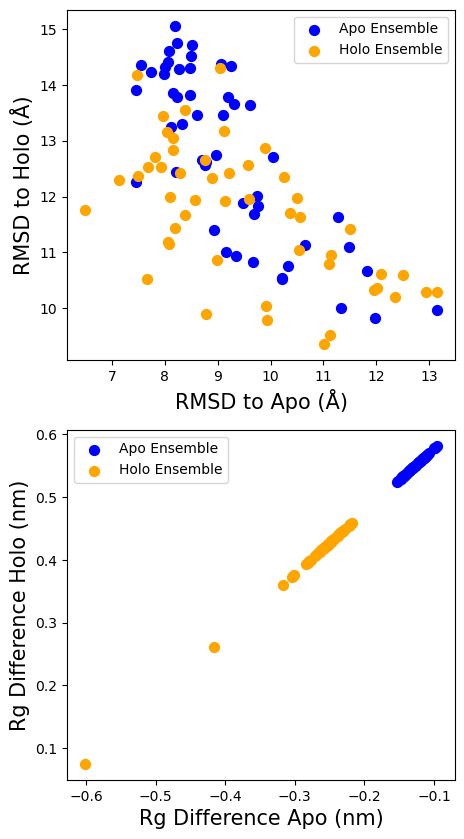

In [41]:
analysis_plot(ref_path, output_path, '1JFJ-3_A', '1JFK_A')

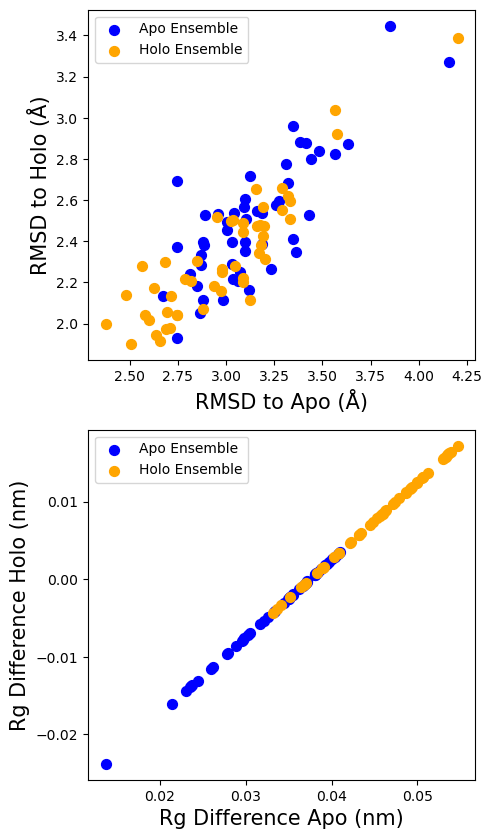

In [42]:
analysis_plot(ref_path, output_path, '1TJD_A', '1EEJ_B')